In [1]:
import os

# Subir un nivel respecto a la carpeta actual
os.chdir("..")

import numpy as np
from globals import SAMPLE_RATE, PROCESSORS
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.signal import find_peaks

from Utils import load_parameters_file, from_matrix_to_preset, MSE, denormalize_preset, normalize_preset, pretty_print, PARAM_NAMES, from_preset_to_matrix, mel_spectrogram, mfcc, spectrogram
from Synth import Synth
import numpy as np
import cma
import matplotlib.pyplot as plt
from multiprocessing import Pool
from parallelEvaluation import evaluate_presets
from scipy.optimize import differential_evolution

In [2]:
def get_audio(audio_path):
    y, _sr = librosa.load(audio_path, sr=SAMPLE_RATE)
    y = np.array(y, dtype=np.float64)
    y, _ = librosa.effects.trim(y, top_db=15)

    rms_target = 0.1
    rms_actual = np.sqrt(np.mean(y**2))
    scale = rms_target / (rms_actual + 1e-8)
    return y * scale

def split_audio(audio, prominence=0.01):
    win_size = int(0.02 * SAMPLE_RATE)

    rectified_signal = np.abs(audio)
    window = np.ones(win_size) / win_size
    envelope = np.convolve(rectified_signal, window, mode='same')

    minimals, _ = find_peaks(-envelope, prominence=prominence)
    minimals = np.concatenate((np.array([0]), minimals))

    minimals = minimals + (win_size // 2)

    audios = []
    
    for i in range(minimals.shape[0]):
        if i < minimals.shape[0] - 1:
            audios.append(audio[minimals[i] : minimals[i+1]])
        else:
            audios.append(audio[minimals[i]:])

    return audios

In [3]:
def render_presets(presets, duration=0):
    synth = Synth(
        sample_rate=SAMPLE_RATE,
        duration=duration,
        presets=presets
    )
    return synth.process_audio().astype(np.float64)

def evaluate_target(audio):
    return mel_spectrogram(audio, sr=SAMPLE_RATE, n_fft=2048, hop_length=256, n_mels=128)

In [4]:
def search_with_DE(target_C, duration):
    bounds = [(0, 1)] * len(PARAM_NAMES)

    with Pool(PROCESSORS) as pool:
        def get_fitness(solutions):
            solutions = np.array(solutions).T
            solutions_splitted = np.array_split(solutions, PROCESSORS)
            presets_splitted = [(denormalize_preset(from_matrix_to_preset(chunk)), target_C, duration) for chunk in solutions_splitted]
            
            solutions_evaluated = pool.map(evaluate_presets, presets_splitted)
            return np.concatenate(solutions_evaluated).tolist()
            
        result = differential_evolution(
            get_fitness,
            bounds=bounds,
            popsize=10,        # 10 × n_params individuos
            mutation=(0.5, 1),
            recombination=0.7,
            tol=1e-4,
            maxiter=120,
            polish=False,
            seed=None,
            disp=False,
            workers=1,
            vectorized=True,
            strategy='rand1bin'
        )

        x_best = result.x
        f_best = result.fun

        return x_best

In [5]:
def search_with_CMA(target_C, duration, x0):
    sigma0 = 0.03

    with Pool(PROCESSORS) as pool:
        def get_fitness(solutions):
            solutions = np.array(solutions)
            solutions_splitted = np.array_split(solutions, PROCESSORS)
            presets_splitted = [(denormalize_preset(from_matrix_to_preset(chunk)), target_C, duration) for chunk in solutions_splitted]
            
            solutions_evaluated = pool.map(evaluate_presets, presets_splitted)
            return np.concatenate(solutions_evaluated)
        
        bestever = cma.optimization_tools.BestSolution()

        for i in range(5):
            options = {
                'popsize': 30,
                'bounds': [np.zeros_like(x0), np.ones_like(x0)],
                'tolfun': 1e-4,
                'tolx': 1e-4,
                'tolfunhist': 1e-4
            }

            es = cma.CMAEvolutionStrategy(x0, sigma0, options)
            gen = 1

            while not es.stop():
                solutions = np.array(es.ask())  # devuelve una lista de individuos

                fitnesses = get_fitness(solutions)

                best_idx = np.argmin(fitnesses)          # índice del mejor fitness
                best_fitness = fitnesses[best_idx]       # fitness correspondiente

                # if gen % 100 == 0:
                #     print("Gen", gen, "Mejor fitness:", best_fitness, "Sigma", es.sigma, "Restart", i + 1)

                es.tell(solutions, fitnesses)  # pasar fitness al algoritmo

                gen += 1

            bestever.update(es.best)
        
        return bestever.get()[0]

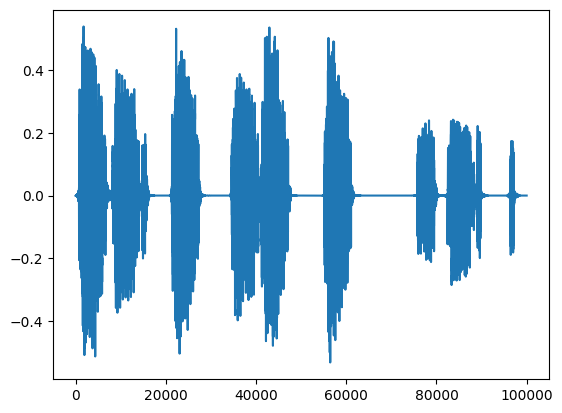

In [6]:
audio_path = 'C:/Users/bryan/Documents/GitHub/Synth/presets/Super Mario Bros. Theme Song.mp3'
audio = get_audio(audio_path)[:100000] # Quitar esto

plt.plot(audio)
plt.show()
Audio(audio, rate=SAMPLE_RATE)

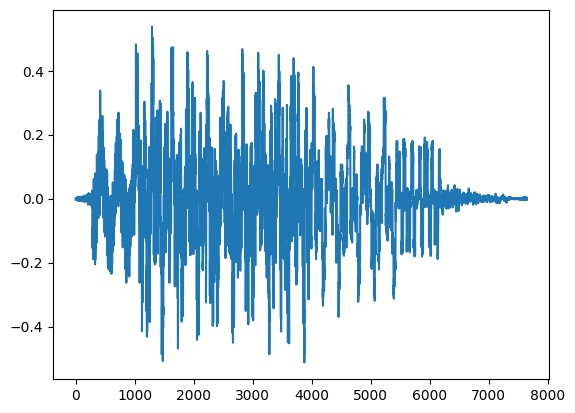

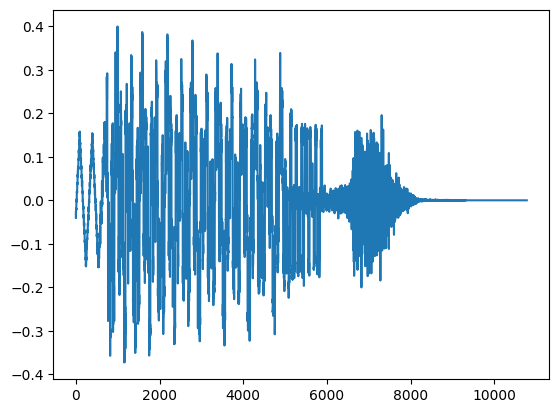

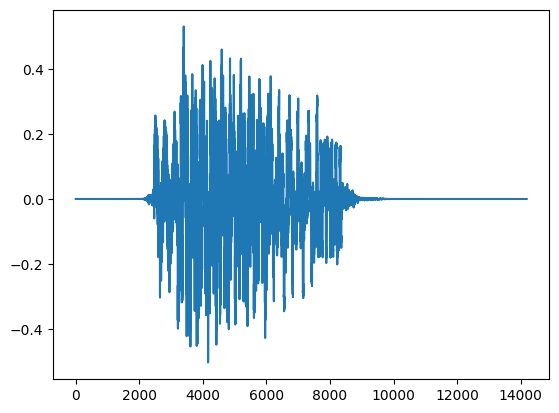

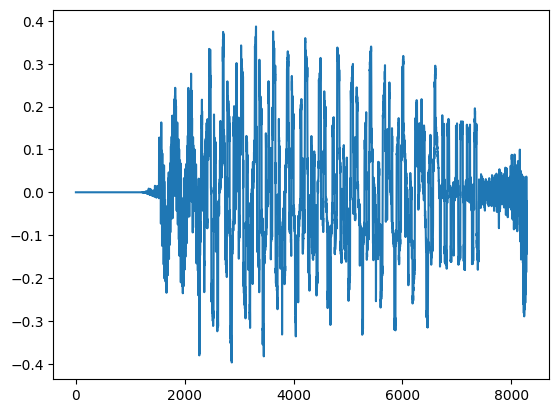

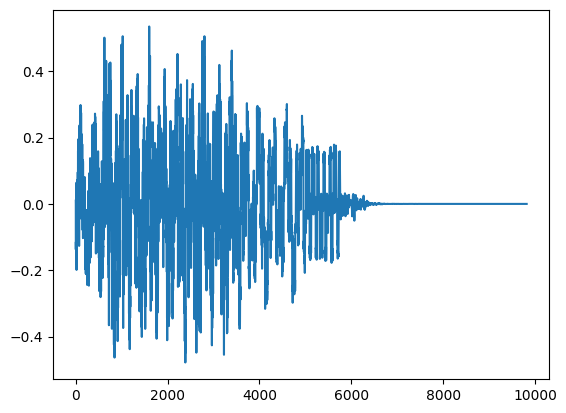

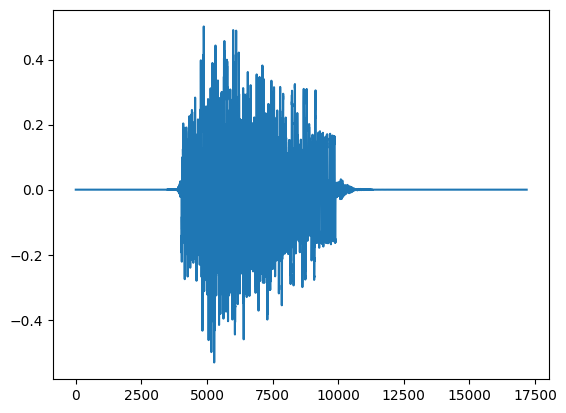

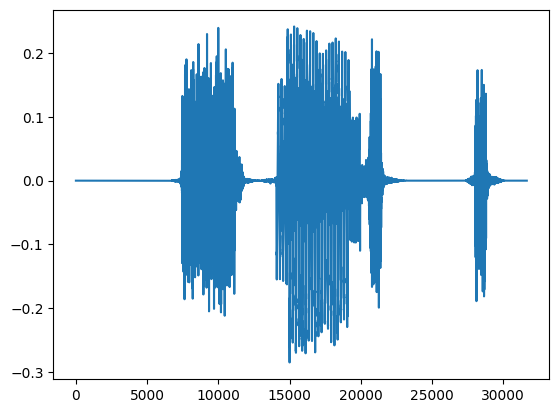

Pieces 7


In [7]:
audio_segments = split_audio(audio, prominence=0.09)

for audio_segment in audio_segments:
    plt.plot(audio_segment)
    plt.show()
    display(Audio(audio_segment, rate=SAMPLE_RATE))

print('Pieces', len(audio_segments))

In [8]:
estimated_presets = []
i = 1

if __name__ == '__main__':
    for audio_segment in audio_segments:
        print('Piece', i)
        target_C = evaluate_target(np.expand_dims(audio_segment, axis=0))
        duration = len(audio_segment) / SAMPLE_RATE
        best = search_with_DE(target_C, duration)
        best = search_with_CMA(target_C, duration, best)
        estimated_presets.append((best, duration))
        i+=1

Piece 1


c:\Users\bryan\Documents\GitHub\Synth\venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:487: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=1067078, Sun Feb  1 14:43:33 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=992408, Sun Feb  1 14:45:58 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=1050639, Sun Feb  1 14:47:36 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=1045290, Sun Feb  1 14:50:58 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=1070097, Sun Feb  1 14:53:17 2026)
Piece 2
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=1095325, Sun Feb  1 14:56:43 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=1103653, Sun Feb  1 14:59:17 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=1120263, Sun Feb  1 15:02:00 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=1052283, Sun Feb  1 15:03:35 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=1077902, Sun Feb  1 15:05:34 2026)
Piece 3
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimen

In [9]:
predicted_joined_audio = []

for preset, duration in estimated_presets:
    preset = np.expand_dims(preset, axis=0)
    # error = evaluate_presets((denormalize_preset(from_matrix_to_preset(preset)), target_C, duration))
    # print('Error', error)
    # target_audio = np.expand_dims(audio_segments[0], axis=0)
    predicted_audio = render_presets(denormalize_preset(from_matrix_to_preset(preset)), duration)
    predicted_joined_audio.append(predicted_audio[0])

    denormalized_predicted_preset = denormalize_preset(from_matrix_to_preset(preset))
    pretty_print(denormalized_predicted_preset)

predicted_joined_audio = np.concatenate(predicted_joined_audio, axis=0)

{
  osc1_shape:   [
    2.722124635098263
  ]
  osc1_phase:   [
    0.26343879448810564
  ]
  osc1_volume:   [
    0.29185086877198535
  ]
  osc1_freq:   [
    661.7218079777421
  ]
  osc2_shape:   [
    3.5403694230972262
  ]
  osc2_phase:   [
    0.7915443607788084
  ]
  osc2_volume:   [
    0.047230292078682276
  ]
  osc2_freq:   [
    2593.774779265469
  ]
  osc3_shape:   [
    1.899955927921357
  ]
  osc3_phase:   [
    0.46994463502754147
  ]
  osc3_volume:   [
    0.30977919629948336
  ]
  osc3_freq:   [
    89.20922922805264
  ]
  osc4_shape:   [
    2.812675286913541
  ]
  osc4_phase:   [
    0.25882151876747195
  ]
  osc4_volume:   [
    0.2574765894269865
  ]
  osc4_freq:   [
    124.84990813944098
  ]
  oscnoise_volume:   [
    0.48846244622739177
  ]
  filter_envelope_attack:   [
    0.3657835789664793
  ]
  filter_envelope_decay:   [
    0.03429426962234605
  ]
  filter_envelope_sustain:   [
    0.48472216918965444
  ]
  filter_envelope_release:   [
    0.1835054283769436

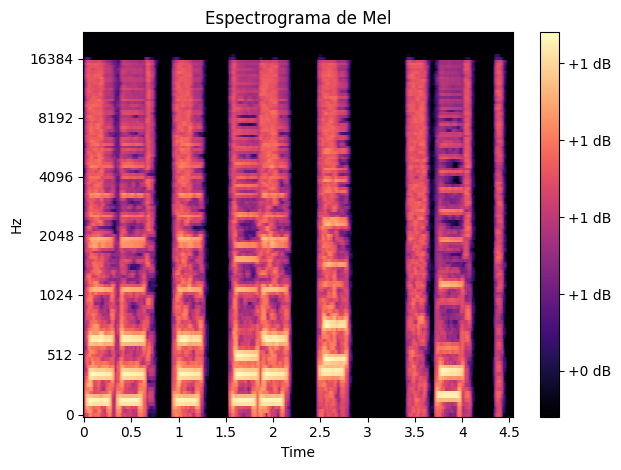

In [10]:
spect = evaluate_target(np.array([audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(audio, rate=SAMPLE_RATE))

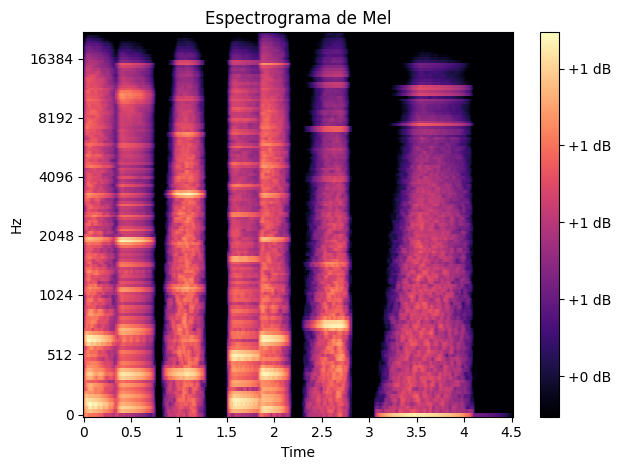

In [11]:
spect = evaluate_target(np.array([predicted_joined_audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(predicted_joined_audio, rate=SAMPLE_RATE))